In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
# import kagglehub
# # Download the RAVDESS dataset
# print("Downloading RAVDESS dataset...")
# dataset_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
# print(f"Dataset downloaded to: {dataset_path}")

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
import kagglehub

# Download the RAVDESS dataset
print("Downloading RAVDESS dataset...")
dataset_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Dataset downloaded to: /kaggle/input/ravdess-emotional-speech-audio


In [11]:
import numpy as np
import os
import glob
import sys
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, Dense, BatchNormalization, Activation, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [12]:
emotions = {
  '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
  '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}

# Update this path if your Kaggle directory structure is different
DATA_PATH = '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/'
MAX_PAD_LEN = 130 # ~3 seconds of audio

def extract_features_improved(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y=y)
        rms = librosa.feature.rms(y=y)

        features = np.concatenate((mfccs.T, chroma.T, mel.T, zcr.T, rms.T), axis=1)

        if features.shape[0] < MAX_PAD_LEN:
            pad_width = MAX_PAD_LEN - features.shape[0]
            features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        else:
            features = features[:MAX_PAD_LEN, :]

        return features
    except Exception as e:
        return None

In [13]:
X, y = [], []
print("Extracting features (this may take a few minutes)...")

for actor_dir in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor_dir)
    if os.path.isdir(actor_path):
        for file_name in glob.glob(os.path.join(actor_path, '*.wav')):
            emotion_code = os.path.basename(file_name).split('-')[2]
            if emotion_code in emotions:
                features = extract_features_improved(file_name)
                if features is not None:
                    X.append(features)
                    y.append(emotions[emotion_code])

print(f"Finished! Loaded {len(X)} samples.")

Extracting features (this may take a few minutes)...
Finished! Loaded 1440 samples.


In [14]:
X = np.array(X)
y = np.array(y)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Compute class weights (fixes the RAVDESS Neutral class imbalance)
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# One-hot encode
ohe = OneHotEncoder()
y_onehot = ohe.fit_transform(y_encoded.reshape(-1, 1)).toarray()

# Scale data
n_samples, n_timesteps, n_features = X.shape
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.reshape(-1, n_features)).reshape(n_samples, n_timesteps, n_features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)

# Save preprocessors for inference later
with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('le.pkl', 'wb') as f: pickle.dump(le, f)

print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (1152, 130, 182), Testing set: (288, 130, 182)


In [15]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # CNN Blocks (Spatial Feature Extraction)
    Conv1D(256, 5, padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(), Activation('relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'), Dropout(0.3),

    Conv1D(128, 5, padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(), Activation('relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'), Dropout(0.3),

    # LSTM Blocks (Temporal Pattern Recognition)
    Bidirectional(LSTM(128, return_sequences=True)), Dropout(0.3),
    Bidirectional(LSTM(64)), Dropout(0.3),

    # Output Layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(), Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 130, 256)       │       233,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 130, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 130, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 65, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 65, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 65, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 33, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 33, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 835,272 (3.19 MB)

 Trainable params: 834,376 (3.18 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150, batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

model.save('ser_cnn_lstm_model.keras')
print("Model saved as 'ser_cnn_lstm_model.keras'")

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.1884 - loss: 2.8062 - val_accuracy: 0.1354 - val_loss: 2.5210 - learning_rate: 0.0010
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2865 - loss: 2.4157 - val_accuracy: 0.2326 - val_loss: 2.3649 - learning_rate: 0.0010
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3585 - loss: 2.2146 - val_accuracy: 0.3542 - val_loss: 2.2299 - learning_rate: 0.0010
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4010 - loss: 2.0692 - val_accuracy: 0.3646 - val_loss: 2.1599 - learning_rate: 0.0010
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4688 - loss: 1.9055 - val_accuracy: 0.4410 - val_loss: 2.0418 - learning_rate: 0.0010
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5052 - loss: 1.7832 - val_accuracy: 0.3646 - val_loss: 2.1081 - learning_rate: 0.0010
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5547 - loss: 1.6439 - 

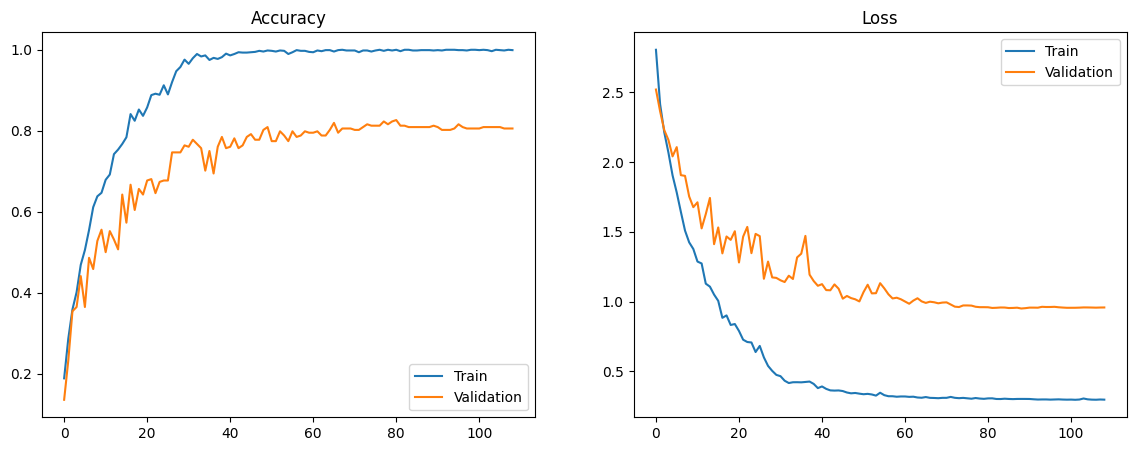

In [17]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

Test Accuracy: 80.90%



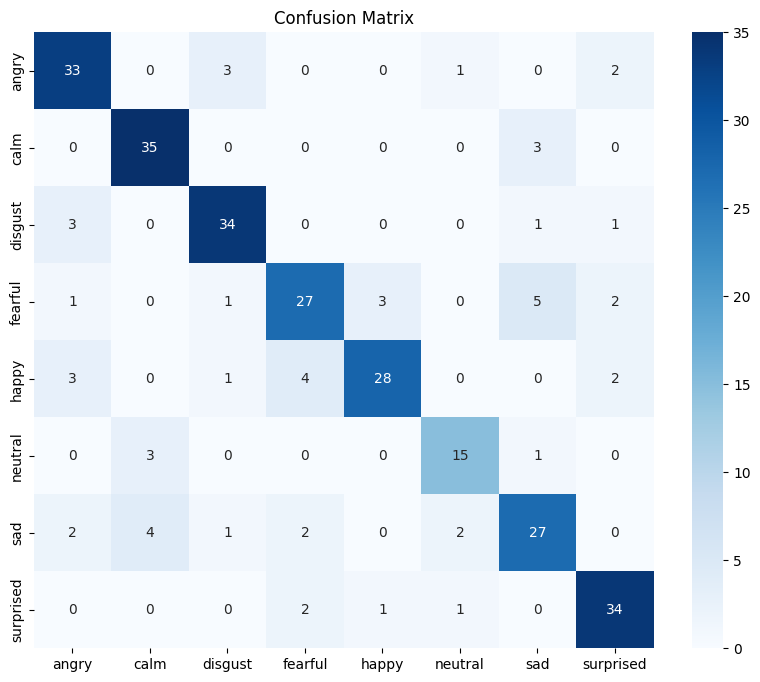

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.show()

In [21]:
print(classification_report(y_true, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       angry       0.79      0.85      0.81        39
        calm       0.83      0.92      0.88        38
     disgust       0.85      0.87      0.86        39
     fearful       0.77      0.69      0.73        39
       happy       0.88      0.74      0.80        38
     neutral       0.79      0.79      0.79        19
         sad       0.73      0.71      0.72        38
   surprised       0.83      0.89      0.86        38

    accuracy                           0.81       288
   macro avg       0.81      0.81      0.81       288
weighted avg       0.81      0.81      0.81       288

